# 10단계 · 멀티종목 포트폴리오 백테스팅

## 09번 전략을 여러 종목에 동시 적용

09번(단일 종목 + 부분 매수/매도)을 **5개 섹터 대표주**로 확장한다.  
각 종목의 ADX 국면이 달라 동시에 모두 하락장에 빠질 확률이 낮아진다 → **분산투자 효과**

```
09번:  삼성전자 1종목  →  size_series (1D)  →  단일 백테스트
10번:  5종목 포트폴리오 →  size_df (5컬럼)  →  공유 현금 포트폴리오
```

## 포트폴리오 구성 종목 (WICS 섹터 대표주)

| 종목 | 코드 | WICS 섹터 |
|------|------|----------|
| 삼성전자 | 005930.KS | IT (반도체) |
| SK하이닉스 | 000660.KS | IT (메모리) |
| NAVER | 035420.KS | 경기관련소비재 (인터넷) |
| 현대차 | 005380.KS | 경기관련소비재 (자동차) |
| POSCO홀딩스 | 005490.KS | 소재 (철강) |

## 핵심 설계 원칙

```
종목별 최대 비중 = 1 / N = 20%  (N=5)
실제 진입 비중  = ADX 비례 × (1/N)  →  최대 20%, 최소 6%

공유 현금(cash_sharing=True): 5종목이 하나의 현금 풀을 나눠 씀
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from vbt_backtest.portfolio_backtest import (
    load_portfolio_data,
    build_size_df,
    run_portfolio_backtest,
    run_bh_portfolio,
    run_bh_single,
    build_metrics_table,
    plot_equity_curves,
    plot_weight_heatmap,
    plot_contribution,
    plot_diversification,
    plot_yearly_returns,
)

# ── 설정 ────────────────────────────────────────────────────────────────────
START    = '2019-01-01'
END      = '2024-12-31'
FEES     = 0.0015
SLIPPAGE = 0.001

ADX_THRESHOLD = 25.0

TICKERS = {
    '삼성전자':    '005930.KS',
    'SK하이닉스':  '000660.KS',
    'NAVER':      '035420.KS',
    '현대차':      '005380.KS',
    'POSCO홀딩스': '005490.KS',
}
NAMES = list(TICKERS.keys())
N     = len(TICKERS)

print(f'포트폴리오 종목 수: {N}개')
print(f'종목별 최대 비중: {1/N:.0%}')
print(f'ADX threshold={ADX_THRESHOLD}')

포트폴리오 종목 수: 5개
종목별 최대 비중: 20%
ADX threshold=25.0


---
## 1단계 · 5종목 데이터 로드

In [2]:
data = load_portfolio_data(TICKERS, start=START, end=END)

close_df  = data['close']
high_df   = data['high']
low_df    = data['low']
volume_df = data['volume']

print(f'기간  : {close_df.index[0].date()} ~ {close_df.index[-1].date()}')
print(f'거래일: {len(close_df)}일')
print()

print('=== 종목별 시작가 → 종가 (수익률) ===')
for name in NAMES:
    s = close_df[name].iloc[0]
    e = close_df[name].iloc[-1]
    print(f'  {name:10s}: {s:>8,.0f}원 → {e:>8,.0f}원  ({(e/s-1):.1%})')

기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일

=== 종목별 시작가 → 종가 (수익률) ===
  삼성전자      :   32,297원 →   51,969원  (60.9%)
  SK하이닉스    :   56,288원 →  171,782원  (205.2%)
  NAVER     :  114,435원 →  195,872원  (71.2%)
  현대차       :   88,118원 →  197,933원  (124.6%)
  POSCO홀딩스  :  182,284원 →  243,078원  (33.4%)


---
## 2단계 · 종목별 신호 생성 → size_df 구성

각 종목에 09번 전략(partial_auto_strategy)을 독립적으로 적용하고,  
포트폴리오 레벨 비중 `(1/N)`을 곱해 공유 현금 기준으로 변환한다.

```
종목 개별 진입 비중: 0.30 ~ 0.70  (1차 40%, 2차 70%, 횡보 30%)
포트폴리오 비중:     0.06 ~ 0.14  (× 1/5)
```

In [3]:
size_df, signal_counts = build_size_df(
    close_df, high_df, low_df, volume_df,
    adx_threshold=ADX_THRESHOLD,
)

import pandas as pd
df_signals = pd.DataFrame(signal_counts).T
print('=== 종목별 신호 횟수 ===')
print(df_signals.to_string())
print()
print(f'size_df 비-NaN 값 범위: {size_df.stack().min():.3f} ~ {size_df.stack().max():.3f}')

=== 종목별 신호 횟수 ===
          진입 횟수  1차 익절  2차 청산
삼성전자         13     12     15
SK하이닉스       15     11      9
NAVER        11     11     13
현대차          18      9     16
POSCO홀딩스     22     13     18

size_df 비-NaN 값 범위: 0.000 ~ 0.140


---
## 3단계 · 포트폴리오 백테스팅 실행

**`group_by=True` + `cash_sharing=True`**:  
5종목이 하나의 현금 풀을 공유 → 진정한 포트폴리오 시뮬레이션

In [4]:
pf_09    = run_portfolio_backtest(close_df, size_df, fees=FEES, slippage=SLIPPAGE)
pf_bh    = run_bh_portfolio(close_df, fees=FEES, slippage=SLIPPAGE)
pf_bh_ss = run_bh_single(close_df['삼성전자'], fees=FEES, slippage=SLIPPAGE)

val_09 = pf_09.value()
val_bh = pf_bh.value()

print(f'09번 포트폴리오 총수익률: {(val_09.iloc[-1]/val_09.iloc[0]-1):.2%}')
print(f'BH 균등포트폴리오 총수익률: {(val_bh.iloc[-1]/val_bh.iloc[0]-1):.2%}')
print(f'삼성전자 단독 BH 총수익률: {pf_bh_ss.total_return():.2%}')

09번 포트폴리오 총수익률: 6.07%
BH 균등포트폴리오 총수익률: 99.21%
삼성전자 단독 BH 총수익률: 60.11%


---
## 4단계 · 자산 곡선 비교

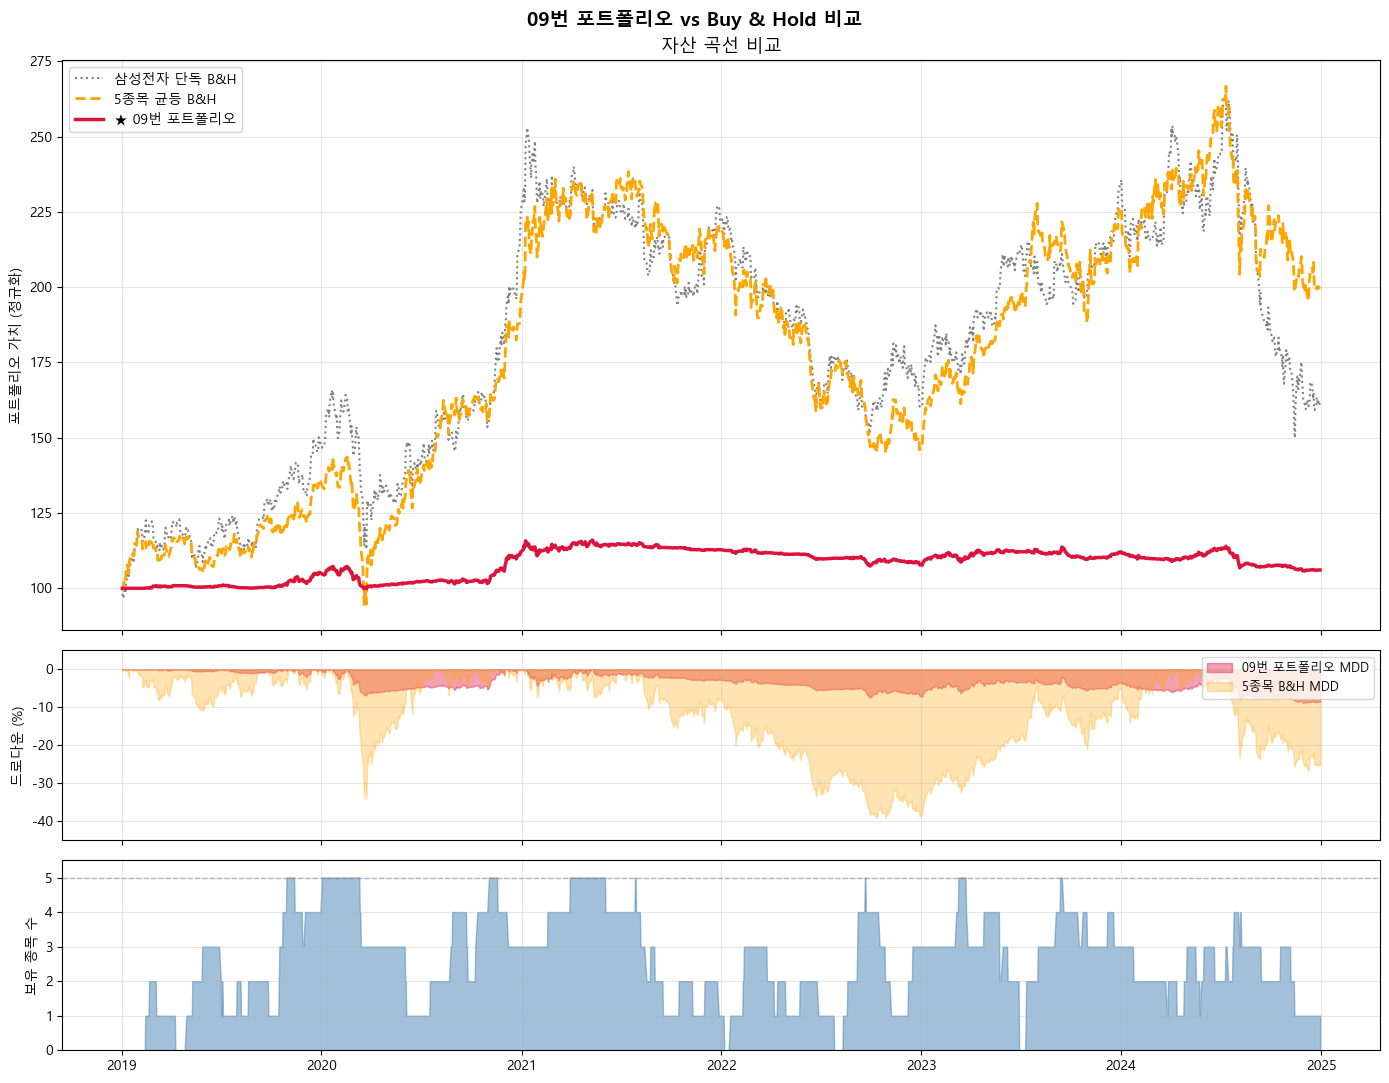

In [5]:
plot_equity_curves(pf_09, pf_bh, pf_bh_ss, names=NAMES, n=N)

---
## 5단계 · 성과 비교 테이블

In [6]:
df_perf = build_metrics_table(pf_09, pf_bh, pf_bh_ss, close_df, bh_ss_name='삼성전자')
print(f'=== 성과 비교 ({close_df.index[0].date()} ~ {close_df.index[-1].date()}) ===')
print(df_perf.to_string())

=== 성과 비교 (2019-01-02 ~ 2024-12-30) ===
                     총 수익률    CAGR  연간 변동성  샤프비율      MDD Calmar
전략                                                              
삼성전자 단독 B&H         60.51%   8.22%  26.27%  0.44  -42.85%   0.19
5종목 균등 B&H          99.21%  12.19%  24.03%  0.61  -39.20%   0.31
★ 09번 포트폴리오          6.07%   0.99%   4.50%  0.25   -8.86%   0.11
  삼성전자 단독 B&H       60.91%   8.26%  26.27%  0.44  -42.85%   0.19
  SK하이닉스 단독 B&H    205.19%  20.46%  38.86%  0.68  -48.19%   0.42
  NAVER 단독 B&H      71.16%   9.38%  35.04%  0.44  -65.45%   0.14
  현대차 단독 B&H       124.62%  14.46%  34.47%  0.57  -52.59%   0.27
  POSCO홀딩스 단독 B&H   33.35%   4.92%  37.24%  0.32  -60.31%   0.08


---
## 6단계 · 포지션 히트맵 (날짜 × 종목)

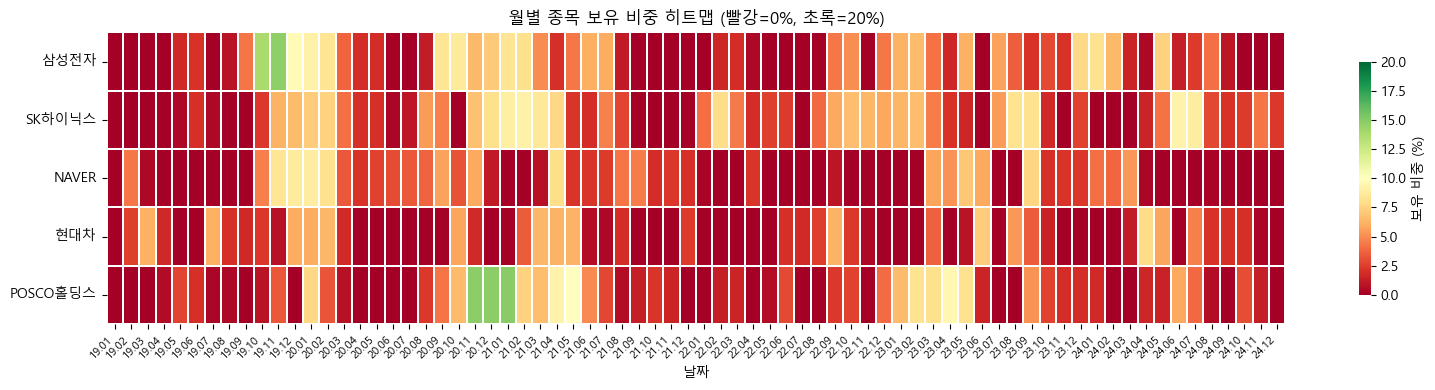


=== 종목별 평균 포지션 비중 ===
  삼성전자      : 3.4%  (최대 15.0%)
  SK하이닉스    : 3.5%  (최대 10.1%)
  NAVER     : 2.2%  (최대 9.2%)
  현대차       : 2.0%  (최대 9.0%)
  POSCO홀딩스  : 3.0%  (최대 15.8%)


In [7]:
plot_weight_heatmap(pf_09, names=NAMES)

---
## 7단계 · 종목별 수익 기여도 분석

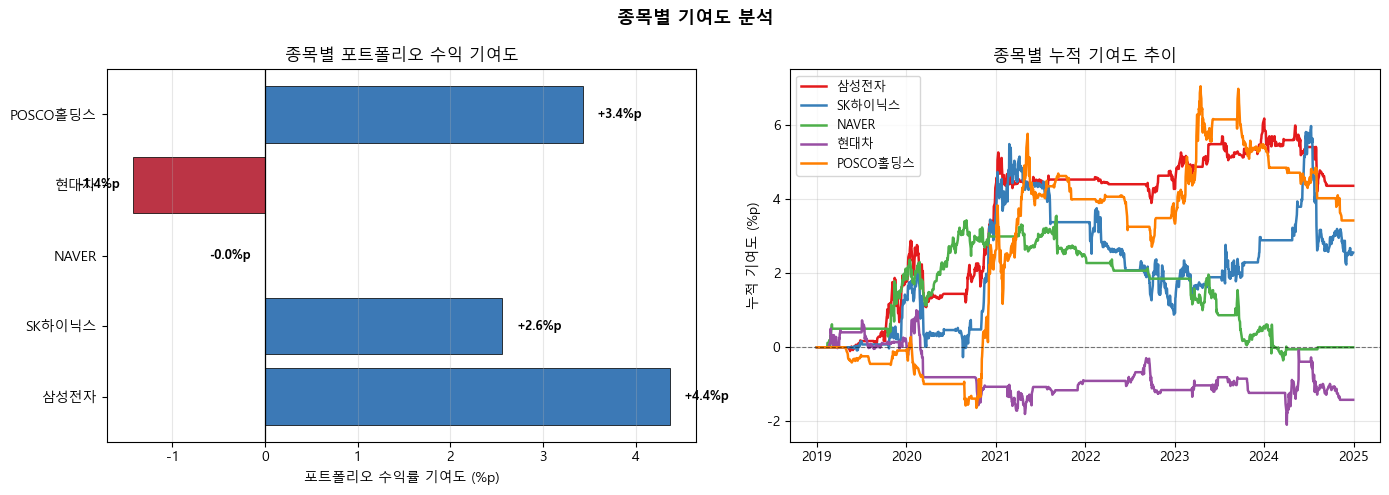


=== 종목별 기여도 순위 ===
  삼성전자      : +4.37%p
  POSCO홀딩스  : +3.43%p
  SK하이닉스    : +2.56%p
  NAVER     : -0.00%p
  현대차       : -1.42%p


In [8]:
plot_contribution(pf_09, close_df, names=NAMES)

---
## 8단계 · 분산투자 효과 분석

**분산투자 효과**: 종목 간 상관관계가 낮을수록 포트폴리오 변동성이 개별 종목보다 낮아진다.

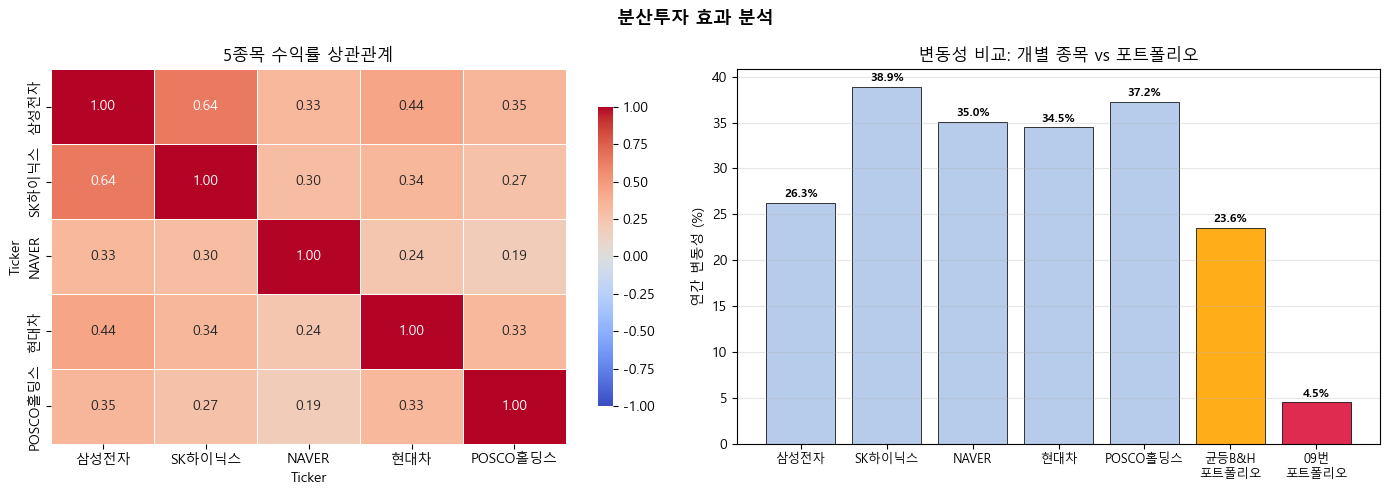


=== 분산투자 효과 ===
개별 종목 평균 변동성: 34.4%
균등 B&H 포트폴리오:  23.6%  (개별 대비 69%)
09번 포트폴리오:       4.5%  (개별 대비 13%)


In [9]:
plot_diversification(pf_09, pf_bh, close_df, names=NAMES)

---
## 9단계 · 연도별 성과 (캘린더 뷰)

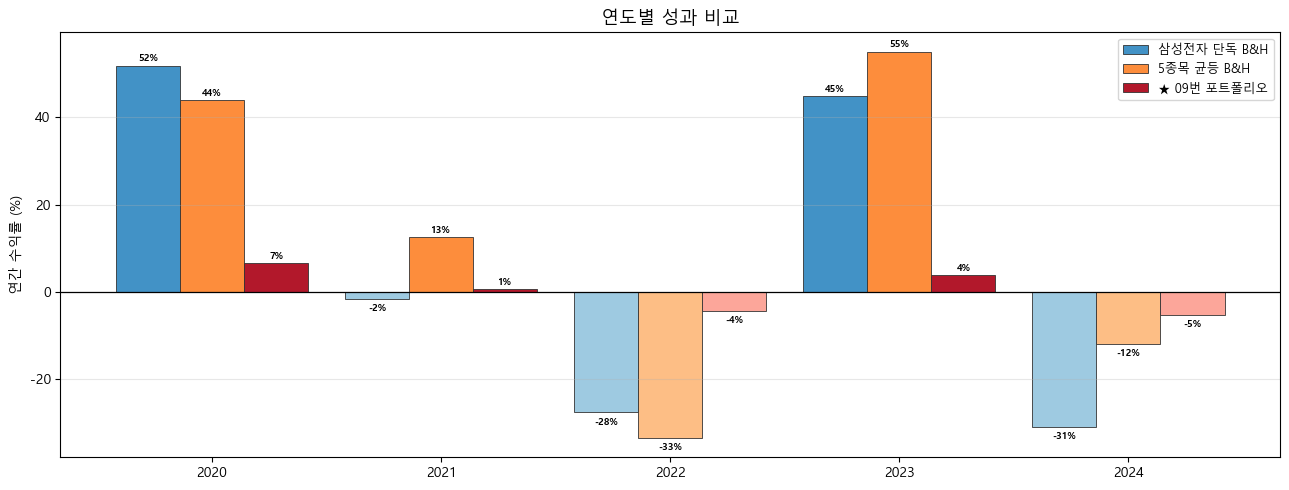

In [10]:
plot_yearly_returns(pf_09, pf_bh, pf_bh_ss, bh_ss_name='삼성전자', n=N)

---
## 정리

### 단일 종목 vs 멀티 포트폴리오

| 구분 | 09번 (삼성 단독) | 10번 (5종목 포트폴리오) |
|------|----------------|---------------------|
| 진입 기회 | 삼성전자 ADX만 의존 | 5종목 중 하나라도 신호 → 진입 |
| 하락 위험 | 삼성 하락 = 전체 손실 | 5종목 동시 하락 가능성 낮음 |
| 변동성 | 개별 종목 변동성 | 분산 효과로 낮아짐 |
| 복잡도 | 단순 | size_df 관리 필요 |

### 분산투자 핵심 공식

```
포트폴리오 변동성 < 개별 종목 평균 변동성
  → 상관관계가 1보다 낮을 때 항상 성립
  → 상관관계가 낮을수록 효과 큼
```

### 다음 개선 방향

```
1. 종목별 Walk-Forward 최적화: 각 종목에 최적 (threshold, scale) 독립 탐색
2. 동적 비중 조절: 변동성 역비례 비중 (낮은 변동성 종목 → 더 많은 비중)
3. 섹터 확장: 5개 → WICS 전체 섹터 대표주 (금융/에너지/헬스케어 추가)
4. 리밸런싱: 월별/분기별 비중 재조정
5. 롱숏: STRONG_BEAR 국면 종목 공매도 (인버스 ETF 활용)
```